# **Importing libraries**

Implementare Time Stretching, Pitch Shifting, Compressione (DRC) e Iniezione di Rumore (BG) per migliorare la robustezza del modello e limitare l'overfitting.

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import torchaudio.transforms as T
import sys
import librosa
import torchvision
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset


import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd

from tqdm import tqdm
%matplotlib inline

from torchsummary import summary
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

from torch.utils.data import Dataset
import glob


# Get Computtional Device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Importing the Dataset

In [3]:
# Percorso base del dataset RAVDESS su Kaggle
# (Kaggle salva automaticamente i dataset nella cartella /kaggle/input/)
DATASET_PATH = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"
emotion_map = {
    0: "neutral", 1: "calm", 2: "happy", 3: "sad",
    4: "angry", 5: "fearful", 6: "disgust", 7: "surprised"
}

# Data Agumentation

Implementare Time Stretching, Pitch Shifting, Compressione (DRC) e Iniezione di Rumore (BG) per migliorare la robustezza del modello e limitare l'overfitting.

In [4]:
def apply_time_stretch(wav, rate):
    return librosa.effects.time_stretch(y=wav, rate=rate)

def apply_pitch_shift(wav, sr, n_steps):
    return librosa.effects.pitch_shift(y=wav, sr=sr, n_steps=n_steps)

def apply_bg_noise(wav):
    # Iniezione di rumore (Background Noise)
    # L'intensità del rumore è tra il 10% e il 50% come specificato nel paper
    # caricare rumori definiti
    noise = np.random.randn(*wav.shape)
    weight = np.random.uniform(0.10, 0.50)
    noisy_wav = wav + weight * noise
    return noisy_wav

def apply_drc_basic(wav):
    # Compressione logaritmica semplice (Dynamic Range Compression)
    return np.sign(wav) * np.log1p(100 * np.abs(wav)) / np.log1p(100)

In [5]:
# Creiamo le cartelle fisiche sull'Hard Disk di Kaggle
os.makedirs('/kaggle/working/processed_data/train', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/val', exist_ok=True)
os.makedirs('/kaggle/working/processed_data/test', exist_ok=True)

Crea il dataset aumentato (Cella da eseguire una sola volta)

In [6]:
def generate_augmented_dataset_ondisk(root_dir=DATASET_PATH):
    
    counters = {'train': 0, 'val': 0, 'test': 0}
    
    all_files = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(".wav"):
                all_files.append(os.path.join(dirpath, f))
                
    for file_path in tqdm(all_files, desc="Estrazione e Salvataggio (16kHz)"):
        filename = os.path.basename(file_path)
        parts = filename.replace(".wav", "").split("-")
        
        if len(parts) != 7: continue
            
        emotion_label = int(parts[2]) - 1 
        speaker_id = int(parts[6])         
        
        # 1. Caricamento Audio Originale
        waveform, sample_rate = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
            
        # --- NUOVO: RICAMPIONAMENTO IMMEDIATO A 16kHz ---
        # Salviamo i file già rimpiccioliti per non intasare il disco di Kaggle!
        if sample_rate != 16000:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            sample_rate = 16000  # Ora è a 16000
        # ------------------------------------------------
            
        wav_np = waveform.squeeze().numpy()
        wav_trimmed, _ = librosa.effects.trim(wav_np, top_db=30)
        wav_orig = librosa.util.normalize(wav_trimmed)
        
        if speaker_id <= 18:
            subset = "train"
        elif 19 <= speaker_id <= 22:
            subset = "val"
        else:
            subset = "test"
            
        def save_file(wav_data, subset_name):
            file_name = f"/kaggle/working/processed_data/{subset_name}/sample_{counters[subset_name]}.pt"
            torch.save((wav_data, sample_rate, emotion_label, speaker_id), file_name)
            counters[subset_name] += 1

        # Salva Originale
        save_file(wav_orig, subset)

        # Applica Data Augmentation (Solo Train)
        if subset == "train":
            # TS
            for rate in [0.81, 0.93, 1.07, 1.23]:
                save_file(apply_time_stretch(wav_orig, rate), "train")
            # PS
            for steps in [-3.5, -2.5, -2, -1, 1, 2, 2.5, 3.5]:
                save_file(apply_pitch_shift(wav_orig, sample_rate, steps), "train")
            # BG
            for _ in range(2):
                save_file(apply_bg_noise(wav_orig), "train")
            # DRC
            save_file(apply_drc_basic(wav_orig), "train")

    print("\n Salvataggio completato con successo (Versione Leggera)!")
    print(f"File generati -> Train: {counters['train']}, Val: {counters['val']}, Test: {counters['test']}")

# Avvia il processo!
generate_augmented_dataset_ondisk()

Estrazione e Salvataggio (16kHz): 100%|██████████| 2880/2880 [06:17<00:00,  7.62it/s]


 Salvataggio completato con successo (Versione Leggera)!
File generati -> Train: 34560, Val: 480, Test: 240


Dataset per il Traning

In [7]:

class FastRavdessDataset(Dataset):
    def __init__(self, folder_path):
        """
        Cerca tutti i file .pt generati nella cartella specifica
        """
        # Trova tutti i percorsi dei file .pt nella cartella
        self.file_paths = glob.glob(f"{folder_path}/*.pt")
        
    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Carica SOLO il singolo file richiesto (Zero stress sulla RAM!)
        file_to_load = self.file_paths[idx]
        wav_np, sample_rate, emotion_label, speaker_id = torch.load(file_to_load, weights_only = False)
        
        wav_norm = librosa.util.normalize(wav_np)
        waveform = torch.tensor(wav_norm, dtype=torch.float32).unsqueeze(0) 
        
        if sample_rate != 16000:
            resampler = T.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            sample_rate = 16000
            
        label_tensor = torch.tensor(emotion_label, dtype=torch.long)
        
        return waveform, sample_rate, label_tensor, speaker_id, 0

DataLoader

In [8]:
# Passiamo i percorsi delle cartelle che abbiamo appena riempito
train_dataset = FastRavdessDataset('/kaggle/working/processed_data/train')
val_dataset   = FastRavdessDataset('/kaggle/working/processed_data/val')
test_dataset  = FastRavdessDataset('/kaggle/working/processed_data/test')

# I dataloader rimangono uguali a prima
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Campioni di training pronti: {len(train_dataset)}")

Campioni di training pronti: 34560


# Verifica Visiva della Data Augmentation

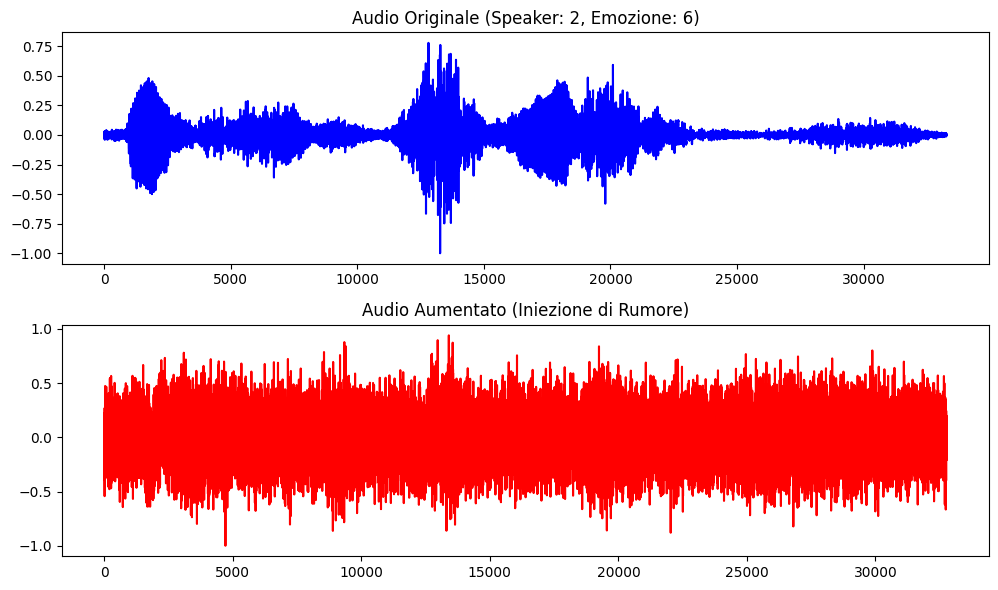

In [9]:
import matplotlib.pyplot as plt

# Seleziona un campione a caso dal tuo nuovo dataset aumentato
idx = 3
waveform, sample_rate, label, speaker_id, _ = train_dataset[idx] # Originale
waveform_noise, _, _, _, _ = train_dataset[idx + 3] # Supponendo che qui ci sia quello con Background Noise

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

# Plot Originale
axs[0].plot(waveform[0].numpy(), color='blue')
axs[0].set_title(f"Audio Originale (Speaker: {speaker_id}, Emozione: {label.item()})")

# Plot Aumentato (es. con Rumore)
axs[1].plot(waveform_noise[0].numpy(), color='red')
axs[1].set_title("Audio Aumentato (Iniezione di Rumore)")

plt.tight_layout()
plt.show()

In [10]:
print(f" Speaker {speaker_id} saying '{label}'")
print()
#Ascolta lo stesso campione con "ipd.Audio(<forma d'onda>, )"
ipd.display(ipd.Audio(waveform.numpy(), rate=sample_rate))

 Speaker 2 saying '6'



Run the following cell and listen to the sample

# Formatting the data
Functions `label_to_index` and `index_to_label` are used to map (and encode) each word with its index in the list of labels.

In [11]:

# 1. Creiamo la mappa inversa
inverse_emotion_map = {v.lower(): k for k, v in emotion_map.items()}

def label_to_index(word):
    return torch.tensor(inverse_emotion_map[word.lower()])

def index_to_label(index):
    if torch.is_tensor(index): index = index.item()
    return emotion_map.get(index, f"Unknown ({index})")

# Test
w = 'Calm'; print(f"{w} → {label_to_index(w)} → {index_to_label(label_to_index(w))}")


Calm → 1 → calm


In [12]:
import torchaudio.transforms as T
import torchvision

n_fft = 1024
win_length = n_fft
hop_length = 160
n_mels = 128
resample_freq = 16000

specgramFn = T.Spectrogram(n_fft=n_fft, win_length=win_length, hop_length=hop_length, power=2.0)
melscaleFn = T.MelScale(n_mels=n_mels, sample_rate=resample_freq, n_stft=n_fft//2+1)
amplitude_to_db_transform = T.AmplitudeToDB(stype='power', top_db=80)
_resizeFn = torchvision.transforms.Resize((64, 128))

In [13]:
_resizeFn   = torchvision.transforms.Resize((64, 128))

def pad_sequence(batch):
    # Uniforma le lunghezze delle WAVEFORM (aggiungendo zeri)
    # Funziona per audio 1D: [canali, tempo]
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):
    tensors, targets = [], []

    for data in batch:
        waveform = data[0]
        label = data[2]
        # Rimuoviamo il canale per fare il padding correttamente sul tempo (diventa [T])
        tensors.append(waveform) 
        
        # Aggiungiamo il target alla lista
        targets.append(label)

    padded_waveforms = pad_sequence(tensors)
    
    spec_tensors = specgramFn(padded_waveforms)
    melspec_tensors = melscaleFn(spec_tensors)
    db_melspec_tensors = amplitude_to_db_transform(melspec_tensors)
    
    mel = _resizeFn(db_melspec_tensors)
   
    targets = torch.stack(targets)

    return mel, targets

batch_size = 64 

if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn, 
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

## Generic functions for training and testing the network model

Now let’s define a *generic* training function that will feed our training data into the model and perform the backward pass and optimization steps. The network will then be tested after each epoch to see how the accuracy varies during the training.

The *generic* function receives as parameters:
* The **trasform** function to apply to the data (or `None`).
* The **criterion** function for computing the loss.
* The **optimizer** to be used during the process.

In [14]:
def train(model, transform, criterion, optimizer, epoch, log_interval,scheduler=None):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):

        data = data.to(device)
        target = target.to(device)
        # 1. Trasformazione
        # apply transform and model on whole batch directly on device
        if transform != None :
          data = data.contiguous()  
          data = transform(data)
        # 2. Forward pass
        output = model(data)
        # negative log-likelihood for a tensor of size (batch x 1 x n_output)
        # 3. loss = F.nll_loss(output.squeeze(), target)
        loss = criterion(output, target)
        # 4. Backward pass e ottimizzazione
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 5. AGGIORNAMENTO SCHEDULER
        if scheduler is not None:
            scheduler.step()

        # print training stats
        if batch_idx % log_interval == 0:
            print()
            print(f"       Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]")
            print(f"       Loss: {loss.item():.6f}")

        # update progress bar
        pbar.update(pbar_update)

        # record loss
        losses.append(loss.item())



Now that we have a *generic* training function, we need to make a *generic* one for testing the networks accuracy. We will set the model to `eval()` mode and then run inference on the test dataset. Calling `eval()` sets the training variable in all modules in the network to false. Certain layers like batch normalization and dropout layers behave differently during training so this step is crucial for getting correct results.

In [15]:
def number_of_correct(pred, target):
    # count number of correct predictions
    return pred.squeeze().eq(target).sum().item()


def get_likely_index(tensor):
    # find most likely label index for each element in the batch
    return tensor.argmax(dim=-1)


def test(model, transform, criterion, epoch):
    model.eval()
    correct = 0
    with torch.no_grad():  # ← aggiungi questo
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)

            if transform != None:
                data = data.contiguous()  
                data = transform(data)    

            output = model(data)
            loss = criterion(output, target)
            pred = get_likely_index(output)
            correct += number_of_correct(pred, target)
            pbar.update(pbar_update)

    print(f"\nTest Epoch: {epoch}\tAccuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n")

Define a *generic* predictor end evaluate function to be used in the evaluation phase.

In [16]:
def evaluate_model(model, test_loader, device, transform=None, classes=None):
    
    model.eval() 
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            target = target.to(device)
            
            # PASSO 1: Applica la trasformazione (se esiste)
            if transform is not None:
                data = data.contiguous() # <-- Ricordi l'errore di prima? Serve anche qui!
                data = transform(data)
            
            # PASSO 2: Fai la predizione
            output = model(data)
            
            # PASSO 3: Ottieni l'indice della classe più probabile
            preds = output.argmax(dim=-1)
            
            # PASSO 4: Salva le predizioni
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
    # --- CALCOLO METRICHE (Richieste dal Progetto) ---
    
    # 1. Accuracy
    acc = accuracy_score(all_targets, all_preds)
    
    # 2. F1-Score
    # Usiamo 'weighted' perché calcola la media pesata in base al numero di campioni 
    # per ogni classe (ottimo se il dataset è un po' sbilanciato)
    f1 = f1_score(all_targets, all_preds, average='macro')
    
    # 3. Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    print("\n" + "="*40)
    print("RISULTATI FINALI SUL TEST SET")
    print("="*40)
    print(f"Accuracy Generale: {acc * 100:.2f}%")
    
    print(f"F1-Score (Macro): {f1:.4f}")
    
    if classes is None:
        classes = [emotion_map[i] for i in range(len(cm))]
    # --- PLOT DELLA MATRICE DI CONFUSIONE ---
    # Questa parte fa molta scena nelle presentazioni e ti aiuta nella "Qualitative Error Analysis"
    # richiesta nel documento (es. per vedere se confonde "happy" con "surprised")
    
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    plt.xlabel('Predizione del Modello')
    plt.ylabel('Emozione Reale')
    plt.title('Matrice di Confusione (Confusion Matrix)')
    plt.show()
    
    return acc, f1, cm

## Mel spectrogram model (with 2D transformation)
**Task: Mel Spectrogram Transform.** Starting from the data visualization section where the Mel Spectrogram of a sample has been computed, build _transform pipeline_ to convert the audio samples to the Mel spectrogram representation.

* H: check the shape of the 2D array before using it as input to the model, i.e. the number of bins (values) both in the time and frequency domain.



La forma (shape) del tensore finale dbmelspec sarà generalmente nel formato:$$\text{Shape} = (\text{Canali}, \text{Bande Mel}, \text{Frame Temporali})$$
1. Dominio della Frequenza (Asse Y)
- Numero di Bins in Frequenza: Corrisponde al parametro n_mels.
- Valore: 128.
- Significato: Questo è il numero di caratteristiche che il modello vedrà nel dominio della frequenza logaritmica. Ogni riga del tuo spettrogramma rappresenta una banda Mel
2. Dominio del Tempo (Asse X)
- Numero di Bins nel Tempo (Frame): Dipende dalla lunghezza totale della forma d'onda ($\text{Lunghezza}$) e dai parametri n_fft e hop_length.
- Formula: Il numero di frame temporali ($N_{\text{frame}}$) è calcolato approssimativamente come:$$N_{\text{frame}} \approx \lfloor \frac{\text{Lunghezza} - \text{n\_fft}}{\text{hop\_length}} \rfloor + 1$$
- Significato: Questo è il numero di "fotogrammi" temporali dello spettrogramma. Ogni colonna del tuo spettrogramma rappresenta una finestra di tempo che si sposta di $10\ \text{ms}$ (hop_length).

Per i modelli di Deep Learning, il tensore bidimensionale (128 Bande Mel $\times$ X Frame) è l'input principale.

# Network Model

In [17]:

class CRNN(nn.Module):
    """
    CRNN Architecture (Choi et al., 2016):
    - 4x Conv2D (3x3 kernel) + BatchNorm + ELU + MaxPool + Dropout(0.1)
    - AdaptiveAvgPool2d -> (freq=1, time=15)
    - 2-layer GRU
    - Last hidden state -> FC -> num_classes
    
    Input: (batch, 1, n_mels, time_frames)  [mel-spectrogram]
    Output: (batch, num_classes)            [logit scores]
    """

    def __init__(self, num_classes: int, n_channels: int = 68,
                 rnn_hidden: int = 68, rnn_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()

        # ── CNN sub-network ───────────────────────────────────────────────
        # 4 blocchi: Conv2D(3×3) → BatchNorm → ELU → MaxPool → Dropout(0.1)
        # Pooling asimmetrico: riduce la frequenza più velocemente del tempo
        # per preservare abbastanza passi temporali per la GRU.
        #
        # Dimensioni dopo ogni blocco (input: freq=64, time=128):
        #   Block 1: MaxPool(2×2) → (32, 64)
        #   Block 2: MaxPool(2×2) → (16, 32)
        #   Block 3: MaxPool(4×2) → ( 4, 16)
        #   Block 4: MaxPool(4×2) → ( 1,  8)  ← freq=1, time=8 per la GRU

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1,              n_channels,   kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq: 64→32 | time: 128→64
            nn.Dropout(dropout),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(n_channels,   n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq: 32→16 | time:  64→32
            nn.Dropout(dropout),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),   # freq: 16→ 4 | time:  32→16
            nn.Dropout(dropout),
        )
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(n_channels*2, n_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(n_channels * 2),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(4, 2)),   # freq:  4→ 1 | time:  16→ 8
            nn.Dropout(dropout),
        )

           # Garantisce freq=1 e time=8 anche con audio di lunghezza variabile
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 8))
          # ── GRU sub-network ───────────────────────────────────────────────
        # 2-layer GRU come da paper (Sezione 2.4)
        # input_size = feature maps dell'ultimo blocco CNN = n_channels*2
        # seq_len = 8 passi temporali
        self.rnn = nn.GRU(
            input_size=n_channels * 2,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            batch_first=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

        # ── Classificatore ────────────────────────────────────────────────
        # Last hidden state → Linear → 8 emozioni
        # Nessuna Softmax: nn.CrossEntropyLoss la include internamente
        self.fc = nn.Linear(rnn_hidden, num_classes)
     
    def forward(self, x):
        # x: (B, 1, 64, 128)  — mel-spectrogram mono

        # 1. CNN: estrazione feature locali tempo-frequenza
        x = self.conv_block1(x)    # (B,    n_ch, 32, 64)
        x = self.conv_block2(x)    # (B,  2*n_ch, 16, 32)
        x = self.conv_block3(x)    # (B,  2*n_ch,  4, 16)
        x = self.conv_block4(x)    # (B,  2*n_ch,  1,  8)

        # 2. Collassa la dimensione frequenza (freq=1 → squeeze)
        x = self.adaptive_pool(x)  # (B,  2*n_ch,  1,  8)
        x = x.squeeze(2)           # (B,  2*n_ch,  8)

        # 3. Prepara per GRU: (batch, seq_len, features)
        x = x.permute(0, 2, 1)    # (B, 8, 2*n_ch)

        # 4. GRU: aggregazione temporale
        # h_n shape: (num_layers, B, rnn_hidden)
        _, h_n = self.rnn(x)
        x = h_n[-1]                # (B, rnn_hidden) ← last hidden state

        # 5. Classificazione finale
        return self.fc(x)          # (B, num_classes)


# 4. Inizializza il modello con il TUO numero di classi 
NUMERO_EMOZIONI = 8

model_crnn = CRNN(
    num_classes=NUMERO_EMOZIONI,
    n_channels=68,   # Conv1: 68 maps | Conv2-4: 136 maps  (Tabella 1, 0.5M)
    rnn_hidden=68,   # GRU hidden units                    (Tabella 1, 0.5M)
    rnn_layers=2,    # 2-layer GRU                         (Sezione 2.4)
    dropout=0.1      # weak dropout                        (Sezione 2)
)
# ── Shape check ───────────────────────────────────────────────────────────────
_dummy = torch.zeros(2, 1, 64, 128)
with torch.no_grad():
    _out = model_crnn(_dummy)
print(f"Shape check  →  input: {list(_dummy.shape)}   output: {list(_out.shape)}")
assert _out.shape == (2, NUMERO_EMOZIONI), "Shape mismatch!"
print("✅ Forward pass OK\n")

total_params = sum(p.numel() for p in model_crnn.parameters() if p.requires_grad)
print(f"Variante:          0.5M  (n_channels=68, rnn_hidden=68)")
print(f"Parametri totali:  {total_params:,}")
print()
print(model_crnn)

Shape check  →  input: [2, 1, 64, 128]   output: [2, 8]
✅ Forward pass OK

Variante:          0.5M  (n_channels=68, rnn_hidden=68)
Parametri totali:  488,928

CRNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 68, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(68, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(68, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(136, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.1, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(136, 136, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d

Inizio Addestramento su dispositivo: cuda


Epoch 1/30:   0%|          | 0.001838235294117647/1.0 [00:01<12:20, 742.27s/it]


       Train Epoch: 1 [0/34560 (0%)]
       Loss: 2.084327


Epoch 1/30:   2%|▏         | 0.02022058823529412/1.0 [00:05<03:59, 244.73s/it]


       Train Epoch: 1 [640/34560 (2%)]
       Loss: 2.055136


...


       Train Epoch: 30 [33280/34560 (96%)]
       Loss: 1.997469


Epoch 30/30:  98%|█████████▊| 0.9761029411764673/1.0 [03:36<00:05, 240.57s/it]


       Train Epoch: 30 [33920/34560 (98%)]
       Loss: 1.972155


Epoch 30/30: 100%|█████████▉| 0.9999999999999967/1.0 [03:41<00:00, 221.22s/it]



Test Epoch: 30	Accuracy: 49/240 (20%)


RISULTATI FINALI SUL TEST SET
Accuracy Generale: 20.42%
F1-Score (Macro): 0.1517


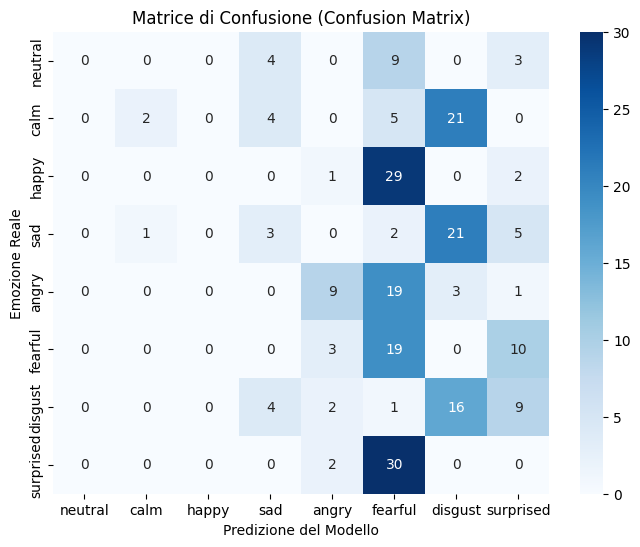

(0.20416666666666666,
 0.1517065277046782,
 array([[ 0,  0,  0,  4,  0,  9,  0,  3],
        [ 0,  2,  0,  4,  0,  5, 21,  0],
        [ 0,  0,  0,  0,  1, 29,  0,  2],
        [ 0,  1,  0,  3,  0,  2, 21,  5],
        [ 0,  0,  0,  0,  9, 19,  3,  1],
        [ 0,  0,  0,  0,  3, 19,  0, 10],
        [ 0,  0,  0,  4,  2,  1, 16,  9],
        [ 0,  0,  0,  0,  2, 30,  0,  0]]))

In [18]:

import torch.optim as optim
from tqdm import tqdm

# Parametri di addestramento
epochs = 30
log_interval = 10
learning_rate = 0.001

# Inizializza modello, loss e ottimizzatore
model = model_crnn.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Variabili globali richieste dalle tue funzioni train/test
losses = []
pbar_update = 1 / (len(train_loader) + len(test_loader))

print(f"Inizio Addestramento su dispositivo: {device}")
print("="*40)

for epoch in range(1, epochs + 1):
    with tqdm(total=1.0, desc=f"Epoch {epoch}/{epochs}") as pbar:
        # Fai il training sul Train Set
        train(model, transform=None, criterion=criterion, optimizer=optimizer, epoch=epoch, log_interval=log_interval, scheduler=scheduler)
        
        # Fai la validazione sul Test Set per vedere come procede
        test(model, transform=None, criterion=criterion, epoch=epoch)

# Valutazione qualitativa finale e matrice di confusione
evaluate_model(model, test_loader, device, transform=None)